# E-commerce Sales & Customer Insights Dashboard

Analysis of a year of e-commerce order data — cleaning, exploratory analysis,
and the charts behind the sales & customer-behavior dashboard.

**Dataset:** 1,200+ synthetic but realistic orders across 5 categories, 4 regions, and 5 payment methods
(built to practice the same skills used in the EduSkills Data Analytics with Python & Power BI internship).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ecommerce_sales_data.csv", parse_dates=["order_date"])
df.head()


## Data Cleaning

Raw data has duplicate orders, a few invalid quantity entries, and some missing payment methods — cleaned below rather than silently dropped.

In [ ]:
before = len(df)
df = df.drop_duplicates(subset=["order_id"])
print(f"Removed {before - len(df)} duplicate orders")

bad_qty = (df["quantity"] <= 0).sum()
df = df[df["quantity"] > 0]
print(f"Removed {bad_qty} rows with invalid quantity")

df["payment_method"] = df["payment_method"].fillna("Unknown")
df["revenue"] = df["quantity"] * df["unit_price"]
df["month"] = df["order_date"].dt.to_period("M").astype(str)

print("Clean shape:", df.shape)


## Key Metrics

In [ ]:
total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()
avg_order_value = df.groupby("order_id")["revenue"].sum().mean()
unique_customers = df["customer_id"].nunique()

print(f"Total revenue: Rs {total_revenue:,.0f}")
print(f"Total orders: {total_orders}")
print(f"Average order value: Rs {avg_order_value:,.0f}")
print(f"Unique customers: {unique_customers}")


## Monthly Revenue Trend

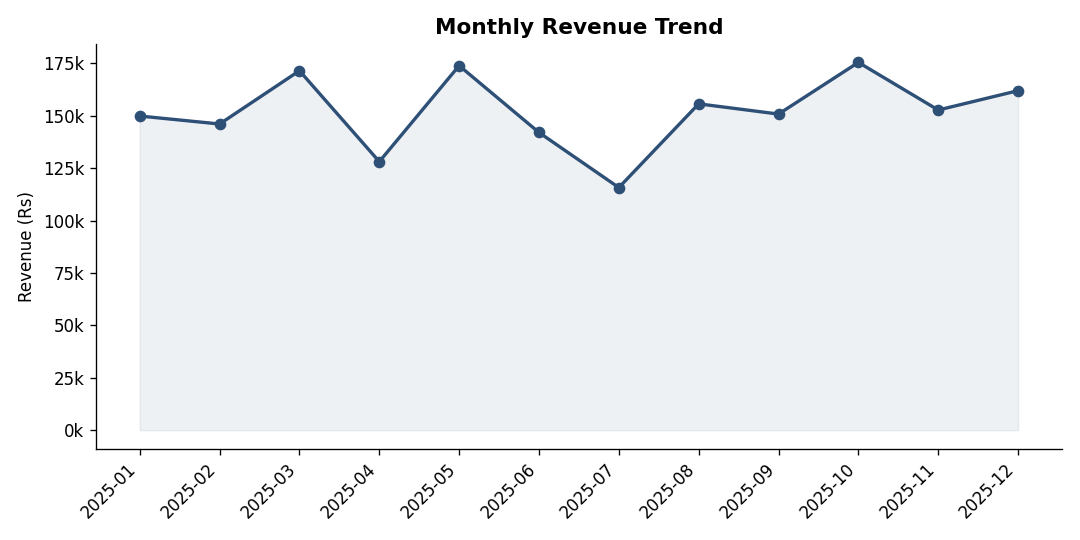

In [1]:
monthly = df.groupby("month")["revenue"].sum().sort_index()
monthly.plot(marker="o", figsize=(9,4.5), title="Monthly Revenue Trend")
plt.show()


## Revenue by Category

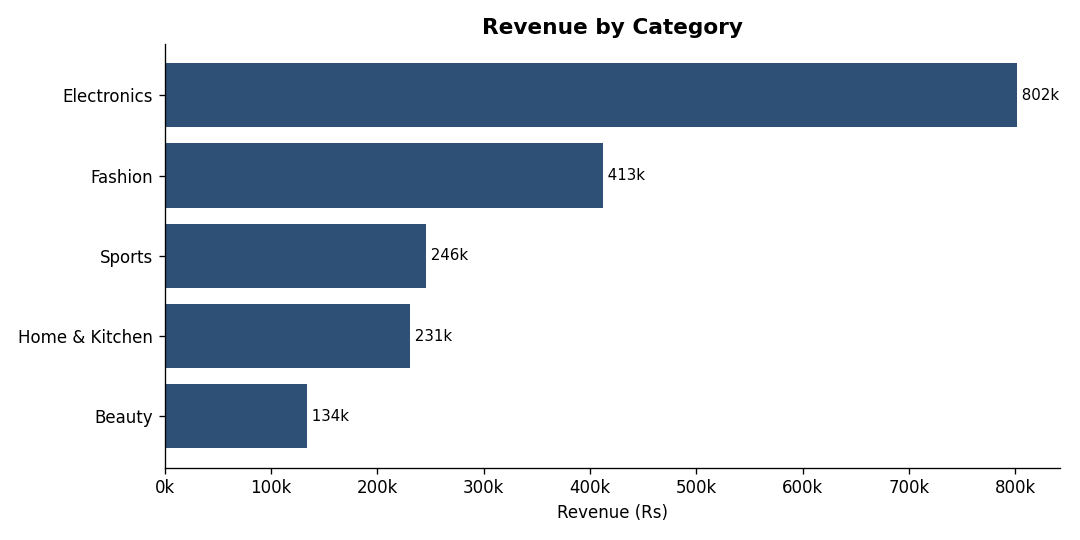

In [1]:
cat_rev = df.groupby("category")["revenue"].sum().sort_values()
cat_rev.plot.barh(figsize=(9,4.5), title="Revenue by Category")
plt.show()


## Revenue Share by Region

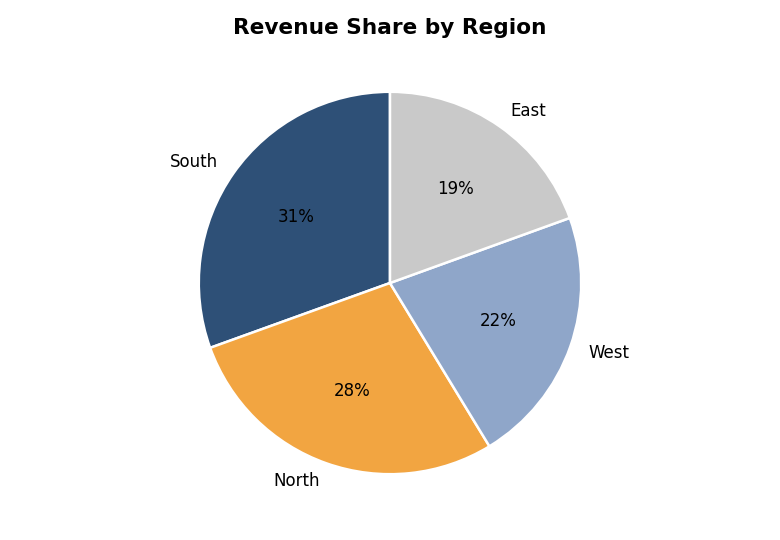

In [1]:
region_rev = df.groupby("region")["revenue"].sum()
region_rev.plot.pie(autopct="%1.0f%%", figsize=(6.5,4.5), title="Revenue Share by Region")
plt.show()


## Top 10 Products by Revenue

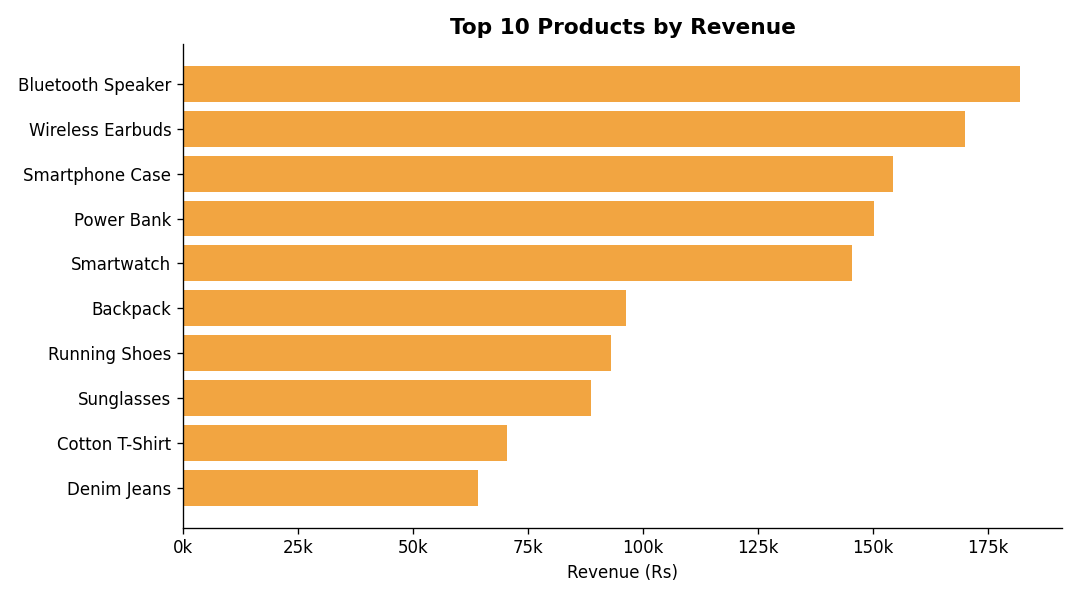

In [1]:
top_products = df.groupby("product")["revenue"].sum().sort_values(ascending=False).head(10)
top_products[::-1].plot.barh(figsize=(9,5), title="Top 10 Products by Revenue")
plt.show()


## Customer Segments: One-time vs Repeat Buyers

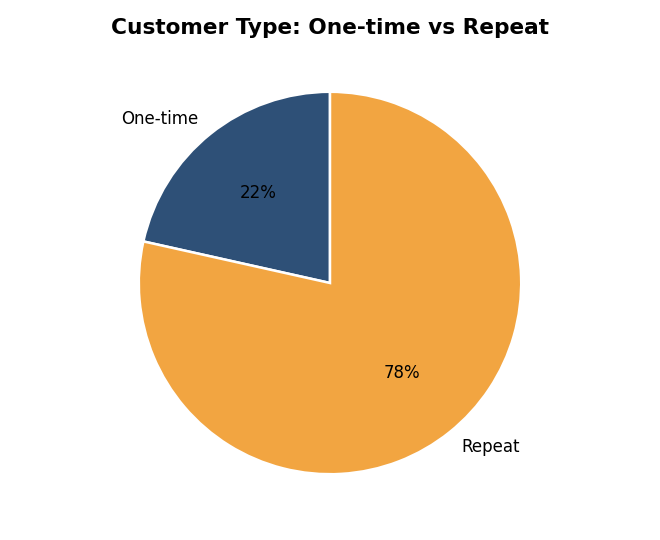

In [1]:
order_counts = df.groupby("customer_id")["order_id"].nunique()
repeat = (order_counts > 1).sum()
new = (order_counts == 1).sum()
pd.Series([new, repeat], index=["One-time","Repeat"]).plot.pie(autopct="%1.0f%%", figsize=(5.5,4.5))
plt.title("Customer Type: One-time vs Repeat")
plt.show()


## Orders by Payment Method

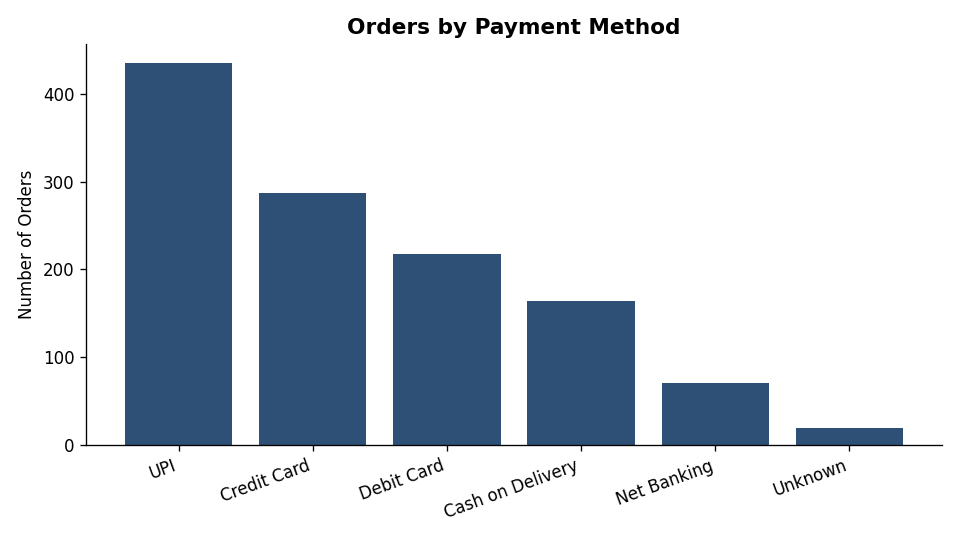

In [1]:
pay_counts = df["payment_method"].value_counts()
pay_counts.plot.bar(figsize=(8,4.5), title="Orders by Payment Method")
plt.show()


## Summary of Insights

```
Total revenue: Rs 1,824,508
Total orders: 1195
Unique customers: 437
Average order value: Rs 1,527
Top category: Electronics (Rs 801,710)
Top region: South (31% of revenue)
Best-selling product: Bluetooth Speaker
Repeat customer rate: 78%

```

**Takeaways used to shape the dashboard:**
- Revenue shows clear month-to-month swings — worth investigating seasonal promotions/campaigns around the dip months.
- A small number of categories and products drive a disproportionate share of revenue — good candidates for inventory prioritization.
- A meaningful share of customers are repeat buyers, suggesting retention campaigns (email/SMS offers) could be high-leverage.
- UPI and Credit Card dominate payments, which should inform checkout flow priorities.
